# Alunos
NATHAN CARDOSO LINHARES  2026010155

PEDRO VINICIUS DE ANDRADE QUEIROZ 2026010152     

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets 
  
# variable information 
display(X) 
display(y) 

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0


,num
0,0
1,2
2,1
3,0
4,0
...,...
298,1
299,2
300,3
301,1


In [28]:
import pandas as pd

df = pd.concat([X, y], axis=1)

display(df)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,3
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1


## Questão 1

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# A 
# Preenche os dados faltantes pela mediana da coluna
df = df.fillna(df.median(numeric_only=True))

# B
# Transforma dos dados da coluna num em binário 0 para 0 e 1, 2, 3 e 4 para 1
df["num"] = df["num"].apply(lambda x: 1 if x > 0 else 0)

# C
# Divisão dos dados entre treino e teste com proporção 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# D
# Escalonamento das colunas contínuas
columns_continues = ["age", "trestbps", "chol", "thalach", "oldpeak"]

scaler = StandardScaler()

X_train[columns_continues] = scaler.fit_transform(X_train[columns_continues])

X_test[columns_continues] = scaler.transform(X_test[columns_continues])

print(X_train[columns_continues])

          age  trestbps      chol   thalach   oldpeak
180 -0.729485 -0.395692  0.458139  0.708371 -0.445445
208  0.050166 -0.054513  0.230598  0.222495 -0.891627
167 -0.061212  0.059213  0.723605  0.399178 -0.891627
105 -0.061212 -1.305501  1.121803  0.266666 -0.891627
297  0.272924  0.514117 -0.167601 -1.190962 -0.713154
..        ...       ...       ...       ...       ...
173  0.829818  0.514117  2.733557  0.310836  0.179210
136  1.720848  0.798433 -1.438042 -1.102621  1.428521
2    1.386712 -0.623144 -0.395142 -0.925938  1.428521
189  1.609469  0.514117  0.078903 -0.175039  0.893102
16  -0.729485 -1.191775 -0.395142  0.796712  0.000737

[242 rows x 5 columns]


## Questão 2

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    solver='liblinear',
    random_state=42,
    max_iter=1000
)

model.fit(X_train, y_train)

print(f'Resultado de interações para convergir {model.n_iter_[0]}')


Resultado de interações para convergir5


## Questão 3

In [54]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_predict= model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

# A - obtendo a curacia
accuracy = accuracy_score(y_test, y_predict)

print(f"Acurácia: {accuracy:.4f}")

# B - obtendo a precisão
precision = precision_score(y_test, y_predict)

print(f"Precisão: {precision:.4f}")

# C - obtendo o recall
recall = recall_score(y_test, y_predict)

print(f"Recall: {recall:.4f}")

# D - obtendo o F1-score
f1 = f1_score(y_test, y_predict)

print(f"F1-score: {f1:.4f}")

# E - obtendo ROC e AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)
print(f"AUC: {auc:.4f}")



Acurácia: 0.8689
Precisão: 0.8125
Recall: 0.9286
F1-score: 0.8667
AUC: 0.9545


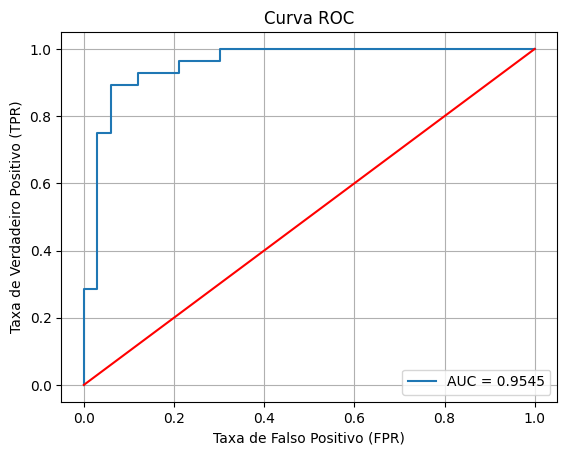

In [51]:
# Grafico da curva de ROC
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="-", color="r")
plt.xlabel("Taxa de Falso Positivo (FPR)")
plt.ylabel("Taxa de Verdadeiro Positivo (TPR)")
plt.title("Curva ROC")
plt.legend()
plt.grid()
plt.show()